# 2D Optical Kagome Superlattice Potential Calculation

This notebook calculates and visualizes a 2D optical kagome superlattice potential by evaluating a 3D superspace potential on a (111) cut. 

## Physics and Geometry
The potential is defined as:
$$ V(X_1, X_2, X_3) = \sum_{i=1}^{3} [r_{i, \text{fund}} V_1 \cos(X_i) + r_{i, \text{harm}} V_2 \cos(2X_i + \theta_i)] $$
where $X_i = k_i \cdot r + \phi_{\text{plane}}$ are the superspace coordinates for a 2D position $r = (x, y)$ on a plane translated by $\phi_{\text{plane}}$, and $r_{i, \text{fund}}, r_{i, \text{harm}}$ are direction-specific depth tuning parameters ($r_{x, \text{fund}}, r_{y, \text{fund}}, r_{z, \text{fund}}$ and $r_{x, \text{harm}}, r_{y, \text{harm}}, r_{z, \text{harm}}$, defaulting to 1).

We use the fundamental wavevectors $K_1, K_2, K_3$ (corresponding to 1064 nm) from `E9_fn.E9_constants` as the base wavevectors $k_i$. The harmonic lattice corresponds to the 532 nm lattice ($k_{532} = 2 K_{1064}$).

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys
import os
from itertools import product, combinations
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Ensure the project root is in the path to allow importing E9_fn
# The script is located in root/projects/superlattice_translation/
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

import E9_fn.E9_constants as E9c

In [54]:
def calculate_kagome_superlattice(V1, V2, Theta, plane_offset = 0.0, x_lims = (-2e-6, 2e-6), y_lims = (-2e-6, 2e-6), res = 500, rx_fund = 1.0, ry_fund = 1.0, rz_fund = 1.0, rx_harm = 1.0, ry_harm = 1.0, rz_harm = 1.0, r_fund = None, r_harm = None):
    """
    Evaluates the 2D optical kagome superlattice potential on a grid with direction-specific depth multipliers.
    
    Args:
        V1 (float): Amplitude of the fundamental (1064 nm) lattice.
        V2 (float): Amplitude of the harmonic (532 nm) lattice.
        Theta (tuple): Phase shifts (theta_1, theta_2, theta_3).
        plane_offset (float): Offset for translating the (111) cut plane in superspace.
        x_lims (tuple): Range for x coordinates in meters.
        y_lims (tuple): Range for y coordinates in meters.
        res (int): Grid resolution.
        rx_fund (float): Multiplier for fundamental lattice in direction 1 (x). Default 1.0.
        ry_fund (float): Multiplier for fundamental lattice in direction 2 (y). Default 1.0.
        rz_fund (float): Multiplier for fundamental lattice in direction 3 (z). Default 1.0.
        rx_harm (float): Multiplier for harmonic lattice in direction 1 (x). Default 1.0.
        ry_harm (float): Multiplier for harmonic lattice in direction 2 (y). Default 1.0.
        rz_harm (float): Multiplier for harmonic lattice in direction 3 (z). Default 1.0.
        r_fund (tuple, optional): Tuple (rx_fund, ry_fund, rz_fund). Overrides individual rx_fund, ry_fund, rz_fund if provided.
        r_harm (tuple, optional): Tuple (rx_harm, ry_harm, rz_harm). Overrides individual rx_harm, ry_harm, rz_harm if provided.
        
    Returns:
        X, Y, V: Grid coordinates and calculated potential.
    """
    if r_fund is None:
        r_fund = (rx_fund, ry_fund, rz_fund)
    if r_harm is None:
        r_harm = (rx_harm, ry_harm, rz_harm)

    # 1. Fundamental wavevectors in rotated coordinates where the (111) plane sits on the x-y axis
    # and the x = 0 plane is a reflection symmetry plane of the 3D cubic superlattice.
    k_lw = E9c.k_lw
    K_vectors = [
        np.array([1 / np.sqrt(2), 1 / np.sqrt(6)]) * k_lw,
        np.array([-1 / np.sqrt(2), 1 / np.sqrt(6)]) * k_lw,
        np.array([0.0, -2 / np.sqrt(6)]) * k_lw
    ]
    
    # 2. Create vectorized 2D spatial grid
    x = np.linspace(x_lims[0], x_lims[1], res)
    y = np.linspace(y_lims[0], y_lims[1], res)
    X, Y = np.meshgrid(x, y)
    
    # Initialize potential array
    V = np.zeros_like(X)
    
    # 3. Vectorized calculation of the potential landscape
    # Formula: V = sum [ r_fund[i] * V1 * cos(Ki . r + offset) + r_harm[i] * V2 * cos(2 * (Ki . r + offset) + theta_i) ]
    # Adhering to strict operator spacing rules.
    for i in range(3):
        Ki = K_vectors[i]
        theta_i = Theta[i]
        rf_i = r_fund[i]
        rh_i = r_harm[i]
        
        # Dot product with plane translation: Xi = Ki_x * x + Ki_y * y + plane_offset
        Xi = Ki[0] * X + Ki[1] * Y + plane_offset
        
        # Accumulate the potential contribution from the i-th axis
        V = V + rf_i * V1 * np.cos(Xi) + rh_i * V2 * np.cos(2 * Xi + theta_i)
        
    return X, Y, V

def visualize_potential(X, Y, V, V1, V2, Theta, plane_offset, rx_fund = 1.0, ry_fund = 1.0, rz_fund = 1.0, rx_harm = 1.0, ry_harm = 1.0, rz_harm = 1.0, r_fund = None, r_harm = None):
    """
    Visualizes the potential using strict object-oriented Matplotlib.
    """
    if r_fund is None:
        r_fund = (rx_fund, ry_fund, rz_fund)
    if r_harm is None:
        r_harm = (rx_harm, ry_harm, rz_harm)

    # Create figure and axis objects
    fig, ax = plt.subplots(figsize = (10, 8))
    
    # Plot potential landscape with 'magma' colormap
    im = ax.pcolormesh(X * 1e6, Y * 1e6, V, cmap = 'viridis', shading = 'auto')
    
    # Apply formatting and labels
    ax.set_aspect('equal')
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    
    title_str = (f'2D Optical Kagome Superlattice Potential\n' + 
                 f'V1 = {V1}, V2 = {V2}, Theta = {Theta}, Plane Offset = {plane_offset}')
    if r_fund != (1.0, 1.0, 1.0) or r_harm != (1.0, 1.0, 1.0):
        title_str += f'\nr_fund = {r_fund}, r_harm = {r_harm}'
    ax.set_title(title_str)
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax = ax)
    cbar.set_label('Potential Energy (a.u.)')
    
    # Optimize layout and display
    plt.tight_layout()
    plt.show()

def animate_kagome_superlattice(V1, V2, Theta, x_lims = (-2.5e-6, 2.5e-6), y_lims = (-2.5e-6, 2.5e-6), res = 300, rx_fund = 1.0, ry_fund = 1.0, rz_fund = 1.0, rx_harm = 1.0, ry_harm = 1.0, rz_harm = 1.0, r_fund = None, r_harm = None, n_frames = 100, fps = 20, output_dir = "videos", filename = None, save_format = "mp4"):
    """
    Generates and saves an animation of the 2D optical kagome superlattice potential
    as the plane_offset is varied from 0 to 2*pi.
    
    Args:
        V1 (float): Amplitude of fundamental lattice.
        V2 (float): Amplitude of harmonic lattice.
        Theta (tuple): Phase shifts (theta_1, theta_2, theta_3).
        x_lims (tuple): Range for x coordinates in meters.
        y_lims (tuple): Range for y coordinates in meters.
        res (int): Grid resolution.
        rx_fund, ry_fund, rz_fund (float): Direction-specific fundamental depth multipliers.
        rx_harm, ry_harm, rz_harm (float): Direction-specific harmonic depth multipliers.
        r_fund, r_harm (tuple, optional): Override directional tuples.
        n_frames (int): Total number of frames for the 0 to 2*pi scan.
        fps (int): Frames per second for video.
        output_dir (str): Subfolder where the video file will be saved.
        filename (str, optional): Custom filename. Auto-generated if None.
        save_format (str): 'mp4' or 'gif'.
        
    Returns:
        filepath (str): Path to the generated video file.
    """
    if r_fund is None:
        r_fund = (rx_fund, ry_fund, rz_fund)
    if r_harm is None:
        r_harm = (rx_harm, ry_harm, rz_harm)

    # Create subfolder if it does not exist
    os.makedirs(output_dir, exist_ok = True)
    
    # Calculate global potential bounds across offsets [0, 2*pi) for constant color scaling
    offsets = np.linspace(0.0, 2 * np.pi, n_frames, endpoint = False)
    V_min, V_max = float('inf'), float('-inf')
    for offset in offsets:
        _, _, V_frame = calculate_kagome_superlattice(
            V1, V2, Theta, plane_offset = offset,
            x_lims = x_lims, y_lims = y_lims, res = res,
            r_fund = r_fund, r_harm = r_harm
        )
        V_min = min(V_min, np.min(V_frame))
        V_max = max(V_max, np.max(V_frame))

    # Initial frame evaluation
    X, Y, V0 = calculate_kagome_superlattice(
        V1, V2, Theta, plane_offset = 0.0,
        x_lims = x_lims, y_lims = y_lims, res = res,
        r_fund = r_fund, r_harm = r_harm
    )

    fig, ax = plt.subplots(figsize = (10, 8))
    im = ax.pcolormesh(X * 1e6, Y * 1e6, V0, cmap = 'viridis', shading = 'auto', vmin = V_min, vmax = V_max)
    
    ax.set_aspect('equal')
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    
    cbar = fig.colorbar(im, ax = ax)
    cbar.set_label('Potential Energy (a.u.)')
    
    def update(frame):
        offset = offsets[frame]
        _, _, V = calculate_kagome_superlattice(
            V1, V2, Theta, plane_offset = offset,
            x_lims = x_lims, y_lims = y_lims, res = res,
            r_fund = r_fund, r_harm = r_harm
        )
        im.set_array(V.ravel())
        
        title_str = (f'2D Optical Kagome Superlattice Potential Evolution\n' + 
                     f'V1 = {V1}, V2 = {V2}, Theta = {Theta}, Plane Offset = {offset / np.pi:.2f}π')
        if r_fund != (1.0, 1.0, 1.0) or r_harm != (1.0, 1.0, 1.0):
            title_str += f'\nr_fund = {r_fund}, r_harm = {r_harm}'
        ax.set_title(title_str)
        return [im]

    anim = animation.FuncAnimation(fig, update, frames = n_frames, blit = False)

    if filename is None:
        filename = f"kagome_evolution_V1_{V1}_V2_{V2}_scan.{save_format}"
    else:
        if not filename.endswith(f".{save_format}"):
            filename = f"{filename}.{save_format}"

    filepath = os.path.join(output_dir, filename)

    plt.tight_layout()
    if save_format.lower() == "mp4":
        try:
            writer = animation.FFMpegWriter(fps = fps, metadata = dict(artist = 'Antigravity'), bitrate = 1800)
            anim.save(filepath, writer = writer)
        except Exception:
            filepath = filepath.rsplit('.', 1)[0] + ".gif"
            writer = animation.PillowWriter(fps = fps)
            anim.save(filepath, writer = writer)
    else:
        writer = animation.PillowWriter(fps = fps)
        anim.save(filepath, writer = writer)

    plt.close(fig)
    print(f"Animation successfully saved to: {filepath}")
    return filepath

def visualize_superspace_plane(plane_offset = 0.0, V1 = -1.0, elev = None, azim = None, show_lattice_planes = True, lattice_plane_alpha = 0.05):
    """
    Visualizes the (111) plane cut in the 3D superspace using object-oriented Matplotlib.
    The plot is in rotated coordinates (x, y, z) where the (111) plane sits on the x-y axis.
    The origin is set at the center of the cube.
    
    Args:
        plane_offset (float): Translation of the plane along the [111] diagonal.
        V1 (float): Amplitude of the fundamental lattice (used to determine minima positions).
        elev (float): Elevation angle for the 3D view (degrees).
        azim (float): Azimuthal angle for the 3D view (degrees).
        show_lattice_planes (bool): If True, shows the constant X1, X2, and X3 planes.
        lattice_plane_alpha (float): Alpha transparency for the constant lattice planes.
    """
    # Create figure with 3D projection
    fig = plt.figure(figsize = (10, 8))
    ax = fig.add_subplot(111, projection = '3d')
    
    # 3D cubic superlattice parameters
    L = 4 * np.pi
    # With origin at the center, the cutting plane offset is relative to the center (2pi, 2pi, 2pi)
    z_plane = np.sqrt(3) * (plane_offset - 2 * np.pi)
    
    # Rotation matrix R mapping (x, y, z) to (X1, X2, X3)
    R = np.array([
        [1/np.sqrt(2), 1/np.sqrt(6), 1/np.sqrt(3)],
        [-1/np.sqrt(2), 1/np.sqrt(6), 1/np.sqrt(3)],
        [0.0, -2/np.sqrt(6), 1/np.sqrt(3)]
    ])
    
    # Vertices of the 3D cubic superlattice of size 2 * lattice_constant centered at origin
    r = [-L/2, L/2]
    vertices = np.array(list(product(r, r, r)))
    rotated_vertices = vertices @ R
    
    # Draw the edges of the cube
    for s_idx, s in enumerate(vertices):
        for e_idx, e in enumerate(vertices):
            if s_idx < e_idx and np.sum(np.abs(s - e)) == L:
                p1 = rotated_vertices[s_idx]
                p2 = rotated_vertices[e_idx]
                ax.plot3D([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color = "green", alpha = 0.7, linewidth = 2)
                
    # Add transparent faces to the cube (using slightly different colors for each face)
    face_indices = [
        [0, 1, 3, 2],
        [4, 5, 7, 6],
        [0, 1, 5, 4],
        [2, 3, 7, 6],
        [0, 2, 6, 4],
        [1, 3, 7, 5]
    ]
    face_colors = ['yellow', 'gold', 'orange', 'lightgreen', 'cyan', 'pink']
    for idx, indices in enumerate(face_indices):
        face_pts = rotated_vertices[indices]
        poly = Poly3DCollection([face_pts], alpha = 0.08, facecolors = face_colors[idx], edgecolors = 'green')
        ax.add_collection3d(poly)
    
    # Draw original cubic axes in the rotated frame (centered at origin, extending to faces)
    for adir, label in [(np.array([L/2, 0, 0]), 'X1'), (np.array([0, L/2, 0]), 'X2'), (np.array([0, 0, L/2]), 'X3')]:
        rot_dir = adir @ R
        ax.plot3D([0, rot_dir[0]], [0, rot_dir[1]], [0, rot_dir[2]], 'k--', alpha = 0.5, linewidth = 2)
        ax.text(rot_dir[0], rot_dir[1], rot_dir[2], f' {label}', color = 'black', fontsize = 10)
        
    # Draw the three-prong coordinate axes (x, y, z) in the rotated frame
    axis_length = 1.2 * L
    ax.plot3D([0, axis_length], [0, 0], [0, 0], color = 'red', linewidth = 2.5)
    ax.text(axis_length + 0.5, 0, 0, 'x', color = 'red', fontsize = 12, fontweight = 'bold')
    ax.plot3D([0, 0], [0, axis_length], [0, 0], color = 'green', linewidth = 2.5)
    ax.text(0, axis_length + 0.5, 0, 'y', color = 'green', fontsize = 12, fontweight = 'bold')
    ax.plot3D([0, 0], [0, 0], [0, axis_length], color = 'blue', linewidth = 2.5)
    ax.text(0, 0, axis_length + 0.5, 'z', color = 'blue', fontsize = 12, fontweight = 'bold')
    
    # Bounding box of the rotated cube
    x_min, y_min, z_min = np.min(rotated_vertices, axis = 0)
    x_max, y_max, z_max = np.max(rotated_vertices, axis = 0)
    
    # Create the horizontal cut plane: z = z_plane
    x_grid = np.linspace(x_min - 8, x_max + 8, 10)
    y_grid = np.linspace(y_min - 8, y_max + 8, 10)
    X_plane, Y_plane = np.meshgrid(x_grid, y_grid)
    Z_plane = np.full_like(X_plane, z_plane)
    
    # Plot the translucent cutting plane surface
    ax.plot_surface(X_plane, Y_plane, Z_plane, alpha = 0.25, color = 'cyan', edgecolor = 'none')
    
    # Find the intersection points of the cube's edges with the cut plane z = z_plane
    intersection_points = []
    for s_idx, s in enumerate(vertices):
        for e_idx, e in enumerate(vertices):
            if s_idx < e_idx and np.sum(np.abs(s - e)) == L:
                p1 = rotated_vertices[s_idx]
                p2 = rotated_vertices[e_idx]
                z_min_edge, z_max_edge = min(p1[2], p2[2]), max(p1[2], p2[2])
                if z_min_edge <= z_plane <= z_max_edge and z_min_edge != z_max_edge:
                    t = (z_plane - p1[2]) / (p2[2] - p1[2])
                    p_inter = p1 + t * (p2 - p1)
                    if not any(np.allclose(p_inter, existing_p, atol=1e-5) for existing_p in intersection_points):
                        intersection_points.append(p_inter)
                        
    # If we have intersection points, draw the cross-section polygon
    if len(intersection_points) >= 3:
        intersection_points = np.array(intersection_points)
        centroid = np.mean(intersection_points, axis = 0)
        angles = np.arctan2(intersection_points[:, 1] - centroid[1], intersection_points[:, 0] - centroid[0])
        sorted_indices = np.argsort(angles)
        sorted_pts = intersection_points[sorted_indices]
        
        loop_pts = np.vstack([sorted_pts, sorted_pts[0]])
        ax.plot3D(loop_pts[:, 0], loop_pts[:, 1], loop_pts[:, 2], color = 'orange', linewidth = 3, label = 'Cross-section Cut')
        
        cross_poly = Poly3DCollection([sorted_pts], alpha = 0.4, facecolors = 'orange', edgecolors = 'none')
        ax.add_collection3d(cross_poly)
        
    # Label the potential minima of the 1064nm lattice
    if V1 < 0:
        coord_vals = [-2 * np.pi, 0.0, 2 * np.pi]
    else:
        coord_vals = [-np.pi, np.pi]
    minima_pts = np.array(list(product(coord_vals, coord_vals, coord_vals)))
    rotated_minima = minima_pts @ R
    
    # Scatter plot with color gradient based on z-coordinate (depth relative to cut plane)
    scatter = ax.scatter(
        rotated_minima[:, 0], rotated_minima[:, 1], rotated_minima[:, 2], 
        c = rotated_minima[:, 2], cmap = 'coolwarm', s = 30, depthshade = False, 
        label = 'Potential Minima'
    )
    
    # Draw constant X1, X2, and X3 planes that go through the lattice points (potential minima)
    if show_lattice_planes:
        # Define colors for X1, X2, and X3 planes (red, green, blue match the original axes directions)
        plane_colors = ['red', 'green', 'blue']
        for axis_idx in range(3):
            color = plane_colors[axis_idx]
            for C in coord_vals:
                # Construct vertices of the square plane in the original cubic coordinates
                if axis_idx == 0:  # X1 = C plane
                    plane_vertices = np.array([
                        [C, -L/2, -L/2],
                        [C, L/2, -L/2],
                        [C, L/2, L/2],
                        [C, -L/2, L/2]
                    ])
                elif axis_idx == 1:  # X2 = C plane
                    plane_vertices = np.array([
                        [-L/2, C, -L/2],
                        [L/2, C, -L/2],
                        [L/2, C, L/2],
                        [-L/2, C, L/2]
                    ])
                else:  # X3 = C plane
                    plane_vertices = np.array([
                        [-L/2, -L/2, C],
                        [L/2, -L/2, C],
                        [L/2, L/2, C],
                        [-L/2, L/2, C]
                    ])
                
                # Rotate the vertices to the plotting coordinate system
                rotated_plane_pts = plane_vertices @ R
                
                # Add the translucent plane to the 3D plot
                poly = Poly3DCollection([rotated_plane_pts], alpha = lattice_plane_alpha, facecolors = color, edgecolors = 'none')
                ax.add_collection3d(poly)
    
    # Turn off default axis grids/panes/labels
    ax.set_axis_off()
    
    # Set custom viewing angle if specified
    if elev is not None or azim is not None:
        ax.view_init(elev = elev, azim = azim)
        
    # Set limits and title
    ax.set_xlim([-10, 10])
    ax.set_ylim([-10, 10])
    ax.set_zlim([-10, 10])
    ax.set_title(f'Rotated 3D Superspace with (111) Cut Plane\nCut Plane z = {z_plane:.2f}')
    
    # Add legend with proxy patch for the lattice planes
    handles, labels = ax.get_legend_handles_labels()
    if show_lattice_planes:
        from matplotlib.patches import Patch
        lattice_patch = Patch(color = 'gray', alpha = 0.3, label = 'Lattice Planes (X1, X2, X3)')
        handles.append(lattice_patch)
        labels.append('Lattice Planes (X1, X2, X3)')
    ax.legend(handles = handles, labels = labels, loc = 'upper left')
    
    # Set aspect ratio to 1:1:1
    ax.set_box_aspect((1, 1, 1))

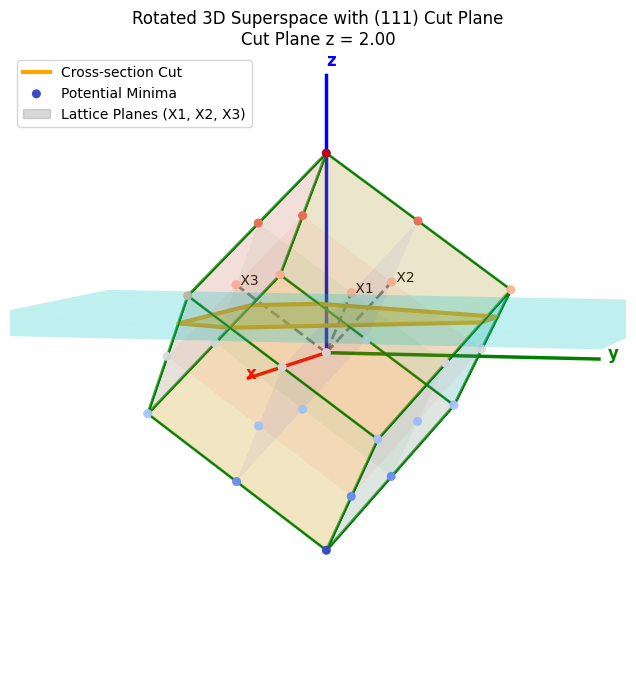

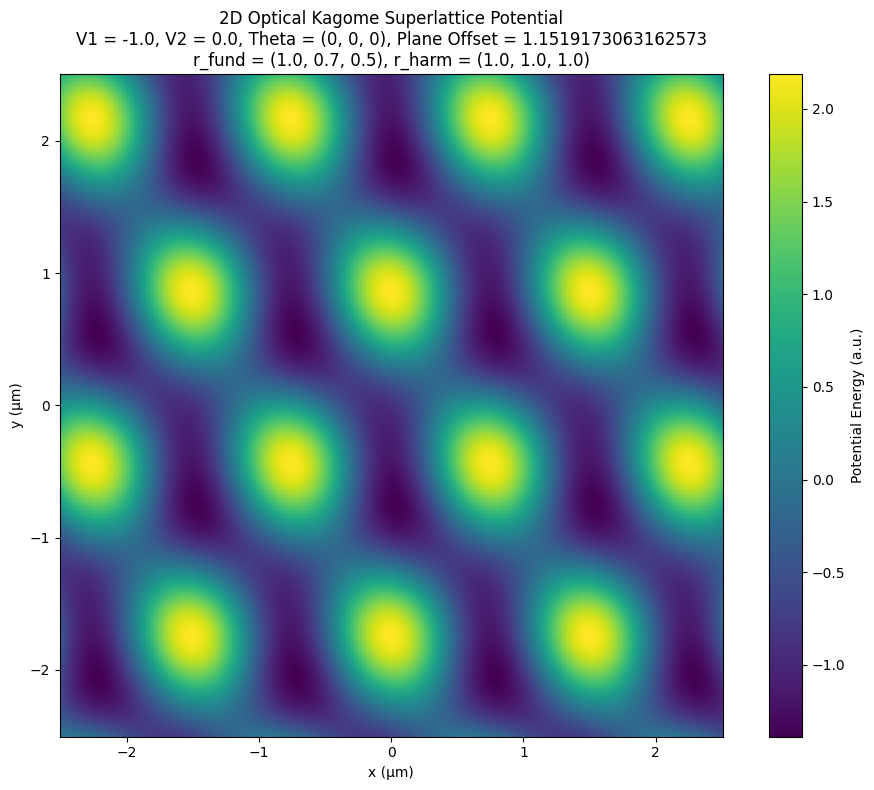

Animation successfully saved to: videos\kagome_plane_offset_scan.gif


In [ ]:
# Example execution
if __name__ == "__main__":
    # Define parameters for the potential
    V_fund = -1.0
    V_harm = 0.
    Phase_shifts = (0, 0, 0)
    # Phase_shifts = (np.pi / 2, np.pi / 2, np.pi / 2)
    # Translation of the plane along the [111] diagonal
    # Geometries are listed for V < 0, 1064nm (fund) only
    Plane_offset = 0            # Triangular
    # Plane_offset = np.pi / 6    # fucked up BN
    Plane_offset = np.pi / 3 + np.pi / 30    # good BN
    # Plane_offset = np.pi / 3    # Honeycomb
    # Plane_offset = np.pi * 2 / 3    # Also Triangular, displaced
    # Plane_offset = np.pi * 2    # Also Triangular, back to 0 offset position
    
    # Optional direction-specific lattice depth tuning (default is all 1.0)
    rx_fund, ry_fund, rz_fund = 1.0, 1.0, 1.0
    rx_harm, ry_harm, rz_harm = 1.0, 1.0, 1.0
    rx_fund, ry_fund, rz_fund = 1.0, 0.7, 0.5   # Maybe Thouless pumping???
    
    # 1. Visualize the 3D superspace cut plane (static)
    visualize_superspace_plane(Plane_offset + 2 * np.pi,
                               azim = 15, elev = 5,
                               show_lattice_planes = True,
                               lattice_plane_alpha = 0.05)
    
    # 2. Calculate the potential landscape on the translated plane (static)
    X_grid, Y_grid, Potential = calculate_kagome_superlattice(
        V_fund, V_harm, Phase_shifts, plane_offset = Plane_offset,
        x_lims = (-2.5e-6, 2.5e-6), 
        y_lims = (-2.5e-6, 2.5e-6),
        rx_fund = rx_fund, ry_fund = ry_fund, rz_fund = rz_fund,
        rx_harm = rx_harm, ry_harm = ry_harm, rz_harm = rz_harm
    )
    
    # 3. Render the 2D potential static visualization
    visualize_potential(X_grid, Y_grid, Potential, V_fund, V_harm, Phase_shifts, Plane_offset,
                        rx_fund = rx_fund, ry_fund = ry_fund, rz_fund = rz_fund,
                        rx_harm = rx_harm, ry_harm = ry_harm, rz_harm = rz_harm)
                        
    # 4. Generate and save animation video as Plane_offset is varied from 0 to 2*pi
    video_path = animate_kagome_superlattice(
        V_fund, V_harm, Phase_shifts,
        x_lims = (-2.5e-6, 2.5e-6),
        y_lims = (-2.5e-6, 2.5e-6),
        res = 200,
        rx_fund = rx_fund, ry_fund = ry_fund, rz_fund = rz_fund,
        rx_harm = rx_harm, ry_harm = ry_harm, rz_harm = rz_harm,
        n_frames = 60,
        fps = 5,
        output_dir = "videos",
        filename = "kagome_plane_offset_scan.gif",
        save_format = "gif"
    )